# Reproduce Current Gating

In [10]:
library(Seurat)
library(tidyverse)
library(mclust)

In [39]:
data_path <- "/nfs/home/students/f.mathis/SysBioMed-PLAs/data/datasets/"
output_dir <- "../../results/gating_automation/"

# "gated_ImmuneAging.rds", "gated_heart_processed.rds", "gated_sepsis_processed.rds", "gated_vaccine_processed.rds", "gated_our_dataset_processed.rds"
file_name <- "gated_heart_processed.rds" 
clean_name <- str_remove(file_name, "\\.rds$")

# "immune_aging", "heart", "sepsis", "vaccine", "our_data"
dataset_type <- "heart"

In [40]:
seurat_obj <- readRDS(paste0(data_path, file_name))
rownames(seurat_obj[["ADT"]])

# Name for CD41: ITGA2B.1, CD41, C0353-CD41
# Name for CD61: ITGB3.1

[1] "FAP.1"           "LRRC15.1"        "CDH11.1"         "CD45"           
  [5] "CDH1.1"          "CD276.1"         "CD45RA"          "GYPA.1"         
  [9] "CD235ab"         "CD45RB"          "CD27.1"          "CD45R"          
 [13] "CD45RO"          "FCGR1A.1"        "KIT.1"           "TNFRSF18.1"     
 [17] "CD207.1"         "CD70.1"          "TNFRSF13C.1"     "TNFSF4.1"       
 [21] "LAG3.1"          "TNFRSF14.1"      "NRP1.1"          "CXCR4.1"        
 [25] "MRC1.1"          "SIRPA.1"         "OLR1.1"          "SLAMF7.1"       
 [29] "PDGFRA.1"        "LILRA4.1"        "PDGFRB.1"        "TNFRSF17.1"     
 [33] "TNFRSF13B.1"     "CSF2RB.1"        "KLRK1.1"         "HAVCR1.1"       
 [37] "CRLF2.1"         "TNFSF13B.1"      "C5AR2.1"         "CLEC4C.1"       
 [41] "CD40LG.1"        "ERBB2.1"         "PDCD1LG2.1"      "CD274.1"        
 [45] "CD80.1"          "IL6ST.1"         "MS4A1.1"         "LTBR.1"         
 [49] "TEK.1"           "CD99.1"          "TRA"             "HLA-E.1"        
 [53] "CD72.1"          "PRNP.1"          "FCGR3A.1"        "FCRL4.1"        
 [57] "ENG.1"           "TNFRSF9.1"       "ABCB1.1"         "CSF2RA.1"       
 [61] "CD36.1"          "NCAM1.1"         "CD151.1"         "FCRL5.1"        
 [65] "CLEC12A.1"       "CD1D.1"          "CD34.1"          "MERTK.1"        
 [69] "CD81.1"          "CD40.1"          "KLRF1.1"         "ABCG2.1"        
 [73] "THY1.1"          "CCR3.1"          "TNFSF9.1"        "SIGLEC7.1"      
 [77] "CEACAM8.1"       "CCR10.1"         "CD164.1"         "MICA-MICB"      
 [81] "IL3RA.1"         "SIGLEC1.1"       "ANXA1.1"         "LRRC32.1"       
 [85] "MSR1.1"          "KDR.1"           "CDH2.1"          "CLEC9A.1"       
 [89] "CSF1R.1"         "FOLR2.1"         "EPCAM.1"         "FLT4.1"         
 [93] "CRTAM.1"         "CD209.1"         "ICOSLG.1"        "ITGA4.1"        
 [97] "TIMD4.1"         "LGALS9.1"        "IL7R.1"          "ENTPD1.1"       
[101] "SLAMF1.1"        "TIGIT.1"         "TPSAB1.1"        "NT5E.1"         
[105] "FCER1A.1"        "SELP.1"          "CD82.1"          "EGFR.1"         
[109] "CLEC1B.1"        "TCR.gamma.delta" "TCRvgamma9"      "TCRvdelta2"     
[113] "DPP4.1"          "CD101.1"         "HLA-A2"          "IL2RA.1"        
[117] "TNFRSF4.1"       "ITGAE.1"         "CD48.1"          "PTGDR2.1"       
[121] "CTLA4.1"         "CR2.1"           "CD135"           "CDH5.1"         
[125] "TNFRSF8.1"       "CD244.1"         "ICOS.1"          "CD79B.1"        
[129] "ICAM2.1"         "CD47.1"          "CD28.1"          "SPN.1"          
[133] "CD7.1"           "CD84.1"          "ADGRG1.1"        "TFRC.1"         
[137] "SDC1.1"          "SELL.1"          "FAS.1"           "KLRD1.1"        
[141] "KIR2DL2"         "KIR3DL1.1"       "CR1.1"           "FCER2.1"        
[145] "PDCD1.1"         "HAVCR2.1"        "ITGB7.1"         "CD69.1"         
[149] "FCGR2A.1"        "Rat.IgG1.lambda" "CXCR3.1"         "CCR6.1"         
[153] "CCR7.1"          "IL4R.1"          "CD163.1"         "LILRB1.1"       
[157] "IFNGR1.1"        "ITGA6.1"         "CLEC10A.1"       "TCRvbeta13.1"   
[161] "IL18R1.1"        "LAMP1.1"         "FCRL3.1"         "CD63.1"         
[165] "ICAM1.1"         "SELE.1"          "CD83.1"          "LY75.1"         
[169] "MME.1"           "CD1A.1"          "CD52.1"          "CD9.1"          
[173] "CD19.1"          "GP1BA.1"         "ITGA2B.1"        "CD38.1"         
[177] "KLRB1.1"         "KIR3DL2.1"       "VPREB1.1"        "TLR4.1"         
[181] "Hamster.IgG"     "IGHD.1"          "ITGAM.1"         "CD44.1"         
[185] "TCR.alpha.beta"  "CD86.1"          "CXCR5.1"         "CCR5.1"         
[189] "CD55.1"          "CX3CR1.1"        "CCR2.1"          "CXCR6.1"        
[193] "SELPLG.1"        "CCR9.1"          "L1CAM.1"         "CD1C.1"         
[197] "HLA-DR"          "CCR8.1"          "CCR4.1"          "CD74.1"         
[201] "CD37.1"          "IGHG1.1"         "LGALS3.1"        "CD14.1"         
[205] "THBD.1"          

# Plot calculated threshold and current gating

[1] "Threshold: 1.52042958644112"


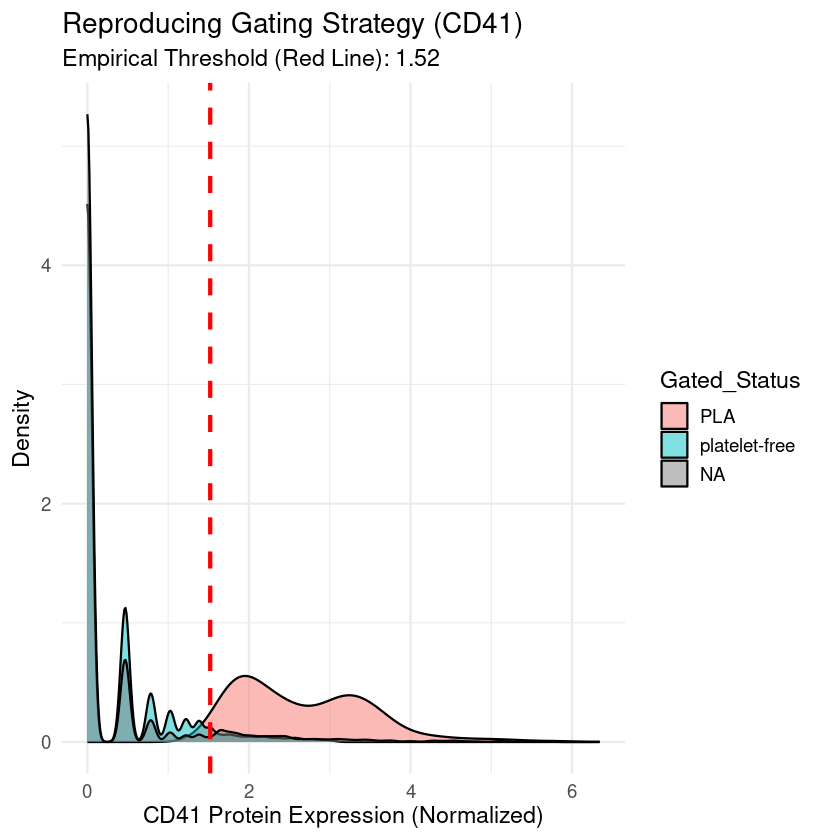

In [ ]:
counts_adt <- GetAssayData(seurat_obj, assay = "ADT", layer = "data")
cd41_expression <- counts_adt["ITGA2B.1", ] 

df_gating <- data.frame(
  CD41 = cd41_expression,
  Gated_Status = seurat_obj@meta.data$pla_status
)

threshold <- min(df_gating$CD41[tolower(df_gating$Gated_Status) == "pla"], na.rm = TRUE)
print(paste("Threshold:", threshold))

p_reproduce <- ggplot(df_gating, aes(x = CD41, fill = Gated_Status)) +
  geom_density(alpha = 0.5, color = "black") +
  geom_vline(xintercept = threshold, linetype = "dashed", color = "red", linewidth = 1.2) +
  theme_minimal(base_size = 14) +
  labs(
    title = "Reproducing Gating Strategy (CD41)",
    subtitle = paste("Empirical Threshold (Red Line):", round(threshold, 3)),
    x = "CD41 Protein Expression (Normalized)", y = "Density"
  )

print(p_reproduce)
ggsave(paste0(output_dir,"reproduced_gating_", clean_name, ".png"), plot = p_reproduce, width = 8, height = 5)

# Recreate Gating

In [38]:
counts_adt <- GetAssayData(seurat_obj, assay = "ADT", layer = "data")
#cd41_expression <- counts_adt["ITGA2B.1", ]
#cd41_expression <- counts_adt["CD41", ]
cd41_expression <- counts_adt["C0353-CD41", ]

df_gmm <- data.frame(
  CD41 = cd41_expression,
  Biologist_Status = seurat_obj@meta.data$pla_status
)

threshold <- min(df_gmm$CD41[tolower(df_gmm$Biologist_Status) == "pla"], na.rm = TRUE)
print(paste("Threshold:", threshold))

gmm_model <- Mclust(df_gmm$CD41, G = 2, verbose = FALSE)

means <- gmm_model$parameters$mean
bg_cluster <- which.min(means)
signal_cluster <- which.max(means)

df_gmm$Predicted_Cluster <- gmm_model$classification

gmm_threshold <- (max(df_gmm$CD41[df_gmm$Predicted_Cluster == bg_cluster]) + 
                  min(df_gmm$CD41[df_gmm$Predicted_Cluster == signal_cluster])) / 2

print(paste("--- DER VERGLEICH ---"))
print(paste("Empirischer Threshold der Biologin:", round(threshold, 4)))
print(paste("Vollautomatisch berechneter GMM-Threshold:", round(gmm_threshold, 4)))

[1] "Threshold: 0.63627045433101"
[1] "--- DER VERGLEICH ---"
[1] "Empirischer Threshold der Biologin: 0.6363"
[1] "Vollautomatisch berechneter GMM-Threshold: 0.3978"


               GMM_Algorithm
Biologist       no_pla   pla
  PLA                0 39405
  platelet-free  81024 16895


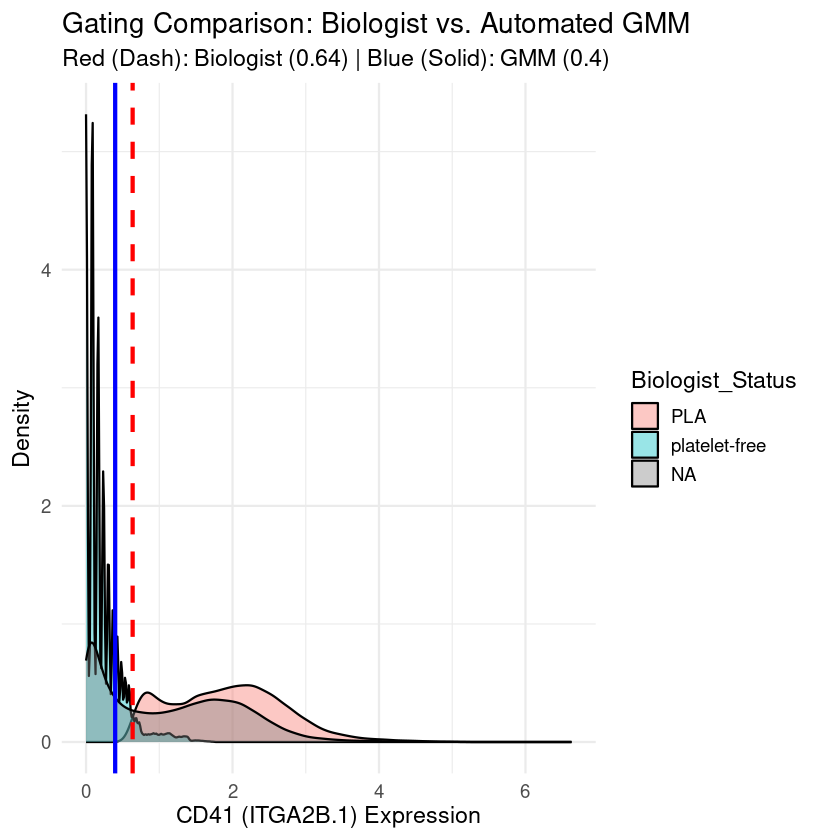

In [39]:
df_gmm <- df_gmm %>%
  mutate(GMM_Status = if_else(CD41 >= gmm_threshold, "pla", "no_pla"))

confusion_matrix <- table(
  Biologist = df_gmm$Biologist_Status,
  GMM_Algorithm = df_gmm$GMM_Status
)

print(confusion_matrix)

p_gmm_vs_bio <- ggplot(df_gmm, aes(x = CD41)) +
  geom_density(aes(fill = Biologist_Status), alpha = 0.4, color = "black") +
  geom_vline(xintercept = threshold, linetype = "dashed", color = "red", size = 1.2) +
  geom_vline(xintercept = gmm_threshold, linetype = "solid", color = "blue", size = 1.2) +
  theme_minimal(base_size = 14) +
  labs(
    title = "Gating Comparison: Biologist vs. Automated GMM",
    subtitle = paste("Red (Dash): Biologist (", round(threshold, 2), ") | Blue (Solid): GMM (", round(gmm_threshold, 2), ")", sep=""),
    x = "CD41 (ITGA2B.1) Expression", y = "Density"
  )

print(p_gmm_vs_bio)
ggsave(paste0(output_dir, "gmm_vs_biologist_gating_", clean_name, ".png"), plot = p_gmm_vs_bio, width = 9, height = 5)

# 2D AUTOMATIC GATING: CD41 (ITGA2B.1) & CD61 (ITGB3.1)

               Quadrant_Algorithm
Biologist       no_pla  pla
  PLA               49  171
  platelet-free   5878  262


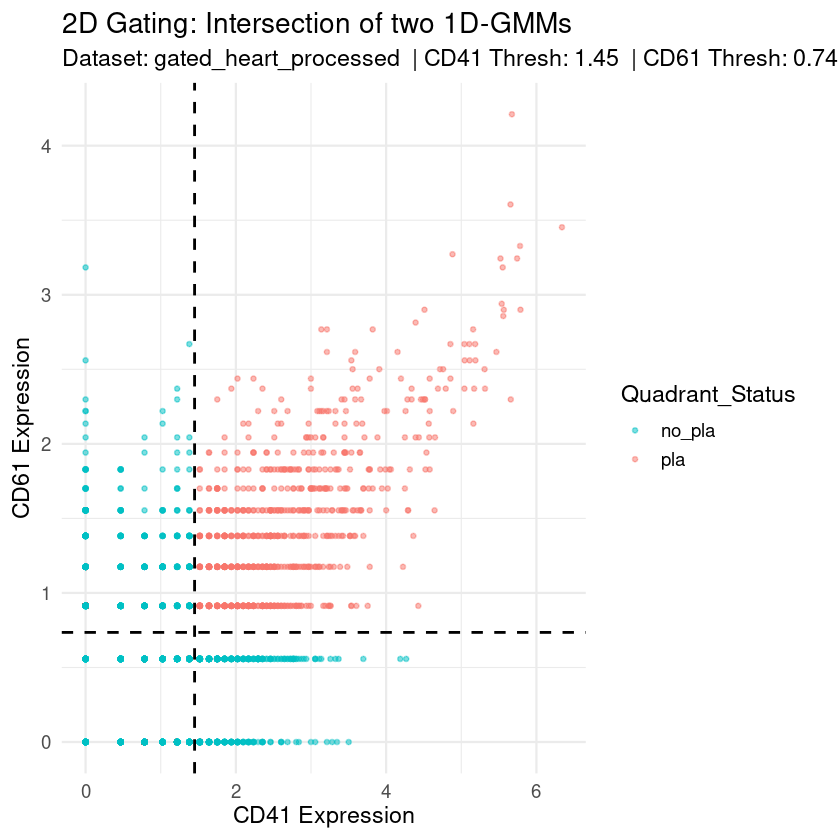

In [42]:
counts_adt <- GetAssayData(seurat_obj, assay = "ADT", layer = "data")
# for immune dateset, instead of CD61: CD62P or CD42b, or C0216-CD42b, C0218-CD62P
# Also: C0353-CD41

df_2d <- data.frame(
  CD41 = counts_adt["ITGA2B.1", ],
  CD61 = counts_adt["ITGB3.1", ],
  Biologist_Status = seurat_obj@meta.data$pla_status,
  CellType = seurat_obj@meta.data$celltype
)

# 1D-GMM für CD41 
gmm_cd41 <- Mclust(df_2d$CD41, G = 2, verbose = FALSE)
thresh_cd41 <- (max(df_2d$CD41[gmm_cd41$classification == which.min(gmm_cd41$parameters$mean)]) + 
                min(df_2d$CD41[gmm_cd41$classification == which.max(gmm_cd41$parameters$mean)])) / 2

# 1D-GMM für CD61 
gmm_cd61 <- Mclust(df_2d$CD61, G = 2, verbose = FALSE)
thresh_cd61 <- (max(df_2d$CD61[gmm_cd61$classification == which.min(gmm_cd61$parameters$mean)]) + 
                min(df_2d$CD61[gmm_cd61$classification == which.max(gmm_cd61$parameters$mean)])) / 2

df_2d <- df_2d %>%
  mutate(Quadrant_Status = if_else(CD41 >= thresh_cd41 & CD61 >= thresh_cd61, "pla", "no_pla"))

# New ground trutz column
seurat_obj@meta.data$automated_pla_status <- df_2d$Quadrant_Status

matrix <- table(
  Biologist = df_2d$Biologist_Status,
  Quadrant_Algorithm = df_2d$Quadrant_Status
)
print(matrix)

# 7. DER DETEKTIV-PLOT FÜR DIE PRÄSENTATION
p_fixed <- ggplot(df_2d, aes(x = CD41, y = CD61, color = Quadrant_Status)) +
  geom_point(alpha = 0.5, size = 1) +
  geom_vline(xintercept = thresh_cd41, linetype = "dashed", color = "black", size = 0.8) +
  geom_hline(yintercept = thresh_cd61, linetype = "dashed", color = "black", size = 0.8) +
  scale_color_manual(values = c("pla" = "#f8766d", "no_pla" = "#00bfc4")) +
  theme_minimal(base_size = 14) +
  labs(
    title = "2D Gating: Intersection of two 1D-GMMs",
    subtitle = paste("Dataset:", clean_name, " | CD41 Thresh:", round(thresh_cd41, 2), " | CD61 Thresh:", round(thresh_cd61, 2)),
    x = "CD41 Expression", y = "CD61 Expression"
  )

print(p_fixed)
ggsave(paste0(output_dir, "2d_quadrant_gating_", clean_name, ".png"), plot = p_fixed, width = 8, height = 6, dpi = 300)